In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"C:\Users\Tejaswi.k\OneDrive\Desktop\datascience coaching\ml\csv files\airlines_customer_satisfaction.csv")

In [3]:
df.isnull().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction    

In [19]:
# # Remove unnecessary dataset
df.drop(['Unnamed: 0', 'id'],axis=1, inplace=True)

In [20]:
##apply median
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(
    df['Arrival Delay in Minutes'].median()
)


In [21]:
##label encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,0,13,1,2,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,1,1,25,0,0,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,0,0,26,0,0,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,0,0,25,0,0,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,1,0,61,0,0,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


In [22]:
##Split Features and Target
x = df.drop('satisfaction', axis=1)
y = df['satisfaction']

In [23]:
print(x.shape)
print(y.shape)

(103904, 22)
(103904,)


In [24]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.05, random_state=7)

In [25]:
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors=5) # init (k = 3)

classifier.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [26]:
y_pred = classifier.predict(x_test)
print("Test Predictions: ", list(y_pred))
print("Actual test data:", list(y_test))
print("*"* 77)

Test Predictions:  [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.in

In [27]:
Error_rate = np.mean(y_pred != y_test)
Error_rate

np.float64(0.2432640492686682)

In [28]:
from sklearn.metrics import accuracy_score

In [29]:
accuracy_score(y_test, y_pred) * 100

75.67359507313319

In [30]:
train_pred = classifier.predict(x_train)
# print("Train Predictions: ", list(train_pred))

In [31]:
accuracy_score(y_train, train_pred) * 100

83.30834380192081

In [32]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Test confusion matrix")
print(confusion_matrix(y_test, y_pred))
print("Train confusion matrix")
print(confusion_matrix(y_train, train_pred))
print(classification_report(y_test, y_pred))
print("Train Accuracy:",accuracy_score(y_train, train_pred)*100)
print("Test Accuracy:",accuracy_score(y_test, y_pred)*100)

Test confusion matrix
[[2340  517]
 [ 747 1592]]
Train confusion matrix
[[49452  6570]
 [ 9906 32780]]
              precision    recall  f1-score   support

           0       0.76      0.82      0.79      2857
           1       0.75      0.68      0.72      2339

    accuracy                           0.76      5196
   macro avg       0.76      0.75      0.75      5196
weighted avg       0.76      0.76      0.76      5196

Train Accuracy: 83.30834380192081
Test Accuracy: 75.67359507313319


In [33]:
error = []
# Calculating error for K values between 1 and 40
for i in range(1,51):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    pred_i = knn.predict(x_test)
    
    error.append(np.mean(pred_i != y_test))
print(error)

[np.float64(0.2763664357197845), np.float64(0.2632794457274827), np.float64(0.24692070823710546), np.float64(0.2449961508852964), np.float64(0.2432640492686682), np.float64(0.2528868360277136), np.float64(0.24692070823710546), np.float64(0.24846035411855275), np.float64(0.24692070823710546), np.float64(0.24865280985373364), np.float64(0.24749807544264818), np.float64(0.2503849114703618), np.float64(0.25057736720554274), np.float64(0.2530792917628945), np.float64(0.2557736720554272), np.float64(0.25519630484988454), np.float64(0.25635103926096997), np.float64(0.2592378752886836), np.float64(0.2592378752886836), np.float64(0.26058506543494997), np.float64(0.2632794457274827), np.float64(0.2632794457274827), np.float64(0.2644341801385681), np.float64(0.264626635873749), np.float64(0.2642417244033872), np.float64(0.2657813702848345), np.float64(0.26250962278675904), np.float64(0.2636643571978445), np.float64(0.2611624326404927), np.float64(0.2642417244033872), np.float64(0.2623171670515781

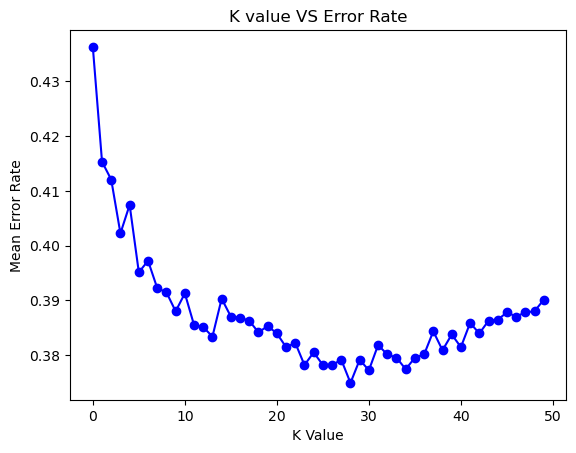

In [18]:
plt.plot(error,color='blue',marker='o')
plt.xlabel('K Value')
plt.ylabel('Mean Error Rate')
plt.title('K value VS Error Rate')
plt.show()